# Machine Learning

This notebook focuses on building and evaluating machine learning models using the prepared student performance dataset.

The main objectives are:

- Prepare the features and target variable for machine learning.
- Split the dataset into training and testing sets.
- Build a Linear Regression model to predict `Final_Exam_Marks`.
- Evaluate the regression model using MAE, MSE, RMSE, and R².
- Build a Logistic Regression model for student performance classification.
- Evaluate the classification model using accuracy, precision, recall, F1-score, and a confusion matrix.
- Interpret the model performance and compare the results.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

## Load the Cleaned Dataset

The cleaned student performance dataset prepared during the data cleaning and feature engineering stages is loaded for machine learning.

The raw dataset is not modified.

In [2]:
df = pd.read_csv("../data/processed/student_performance_cleaned.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2480, 20)

First 5 rows:


,Student_ID,Student_Name,Age,Gender,Department,Semester,Study_Hours_Per_Day,Attendance_Percentage,Previous_Semester_Marks,Assignment_Average,Internal_Test_Marks,Practical_Marks,Participation_Score,Sleep_Hours,Internet_Access,Study_Resources,Backlogs,Final_Exam_Marks,Pass_Fail,Performance_Category
0,S23AIM001,Tanushree Tiwari,20.0,Female,CSE (AI & ML),5,3.50,89.5,76.5,19.0,25.0,40,9.0,7.0,Yes,Textbooks,0.0,77.0,Pass,Very Good
1,S23AIM002,Nitin Kundu,21.0,Male,CSE (AI & ML),5,1.00,71.5,32.0,8.0,4.0,22,7.0,7.0,Yes,Online Courses,4.0,16.0,Fail,Needs Improvement
2,S23AIM003,Amit Laha,21.0,Male,CSE (AI & ML),5,5.50,78.4,82.0,20.0,26.5,45,5.0,6.0,Yes,Notes Only,2.0,80.0,Pass,Very Good
3,S23AIM004,Akash Thakur,21.0,Male,CSE (AI & ML),6,4.00,78.9,67.7,16.5,21.5,38,6.0,5.0,Yes,Online Courses,0.0,63.0,Pass,Good
4,S23AIM005,Aarav Rao,22.0,Male,CSE (AI & ML),6,2.94,65.4,49.0,10.0,13.0,34,6.0,5.0,Yes,Both,0.0,47.0,Pass,Needs Improvement


## Define Features and Target

The target variable for the regression task is `Final_Exam_Marks`.

The following columns are excluded from the input features:

- `Student_ID` and `Student_Name` are identifiers and do not provide useful predictive information.
- `Pass_Fail` and `Performance_Category` are derived from the final exam result and would cause target leakage if used as input features.

In [3]:
X = df.drop(
    columns=[
        "Student_ID",
        "Student_Name",
        "Final_Exam_Marks",
        "Pass_Fail",
        "Performance_Category"
    ]
)

y = df["Final_Exam_Marks"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (2480, 15)
Target shape: (2480,)

Features:
['Age', 'Gender', 'Department', 'Semester', 'Study_Hours_Per_Day', 'Attendance_Percentage', 'Previous_Semester_Marks', 'Assignment_Average', 'Internal_Test_Marks', 'Practical_Marks', 'Participation_Score', 'Sleep_Hours', 'Internet_Access', 'Study_Resources', 'Backlogs']


## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

- 80% of the data is used to train the models.
- 20% is reserved for evaluating model performance on unseen data.
- `random_state=42` is used to ensure reproducible results.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1984, 15)
Testing features: (496, 15)
Training target: (1984,)
Testing target: (496,)


## Data Preprocessing

The dataset contains both numerical and categorical features.

- Numerical features are standardized using `StandardScaler`.
- Categorical features are converted into numerical features using `OneHotEncoder`.
- `handle_unknown="ignore"` ensures that unseen categories in the test set do not cause errors.

The preprocessing is fitted only on the training data to avoid data leakage.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "Gender",
    "Department",
    "Internet_Access",
    "Study_Resources"
]

numerical_features = [
    "Age",
    "Semester",
    "Study_Hours_Per_Day",
    "Attendance_Percentage",
    "Previous_Semester_Marks",
    "Assignment_Average",
    "Internal_Test_Marks",
    "Practical_Marks",
    "Participation_Score",
    "Sleep_Hours",
    "Backlogs"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [6]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (1984, 25)
Processed testing shape: (496, 25)


In [7]:
print("Training data type:", X_train_processed.dtype)
print("Testing data type:", X_test_processed.dtype)

print("\nMissing values in training:",
      np.isnan(X_train_processed).any())

print("Missing values in testing:",
      np.isnan(X_test_processed).any())

Training data type: float64
Testing data type: float64

Missing values in training: False
Missing values in testing: False


## Linear Regression

Linear Regression is used to predict the continuous target variable `Final_Exam_Marks`.

The model is trained using the preprocessed training data and evaluated on the unseen testing data.

In [8]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_processed,
    y_train
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [9]:
y_pred = linear_model.predict(X_test_processed)

print("Number of predictions:", len(y_pred))
print("\nFirst 10 predictions:")
print(y_pred[:10])

Number of predictions: 496

First 10 predictions:
[37.02494457 59.76498961 76.52574939 40.40141015 79.05242646 66.26458942
 64.61132128 76.40818225 47.69756829 44.55835056]


## Linear Regression Evaluation

The Linear Regression model is evaluated using four metrics:

- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted marks.
- **MSE (Mean Squared Error):** Measures the average squared difference between actual and predicted marks.
- **RMSE (Root Mean Squared Error):** Represents the typical prediction error in the same unit as the target variable.
- **R² Score:** Measures how well the model explains the variation in final exam marks.

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE  : 6.2976
MSE  : 62.8945
RMSE : 7.9306
R²   : 0.7462


## Actual vs Predicted Final Exam Marks

The actual and predicted final exam marks are compared to understand how closely the Linear Regression model predicts student performance.

In [11]:
comparison = pd.DataFrame({
    "Actual_Marks": y_test.values,
    "Predicted_Marks": y_pred
})

display(comparison.head(10))

,Actual_Marks,Predicted_Marks
0,40.0,37.024945
1,62.0,59.764990
2,83.0,76.525749
3,52.0,40.401410
4,81.0,79.052426
5,63.0,66.264589
6,68.0,64.611321
7,65.0,76.408182
8,43.0,47.697568
9,52.0,44.558351


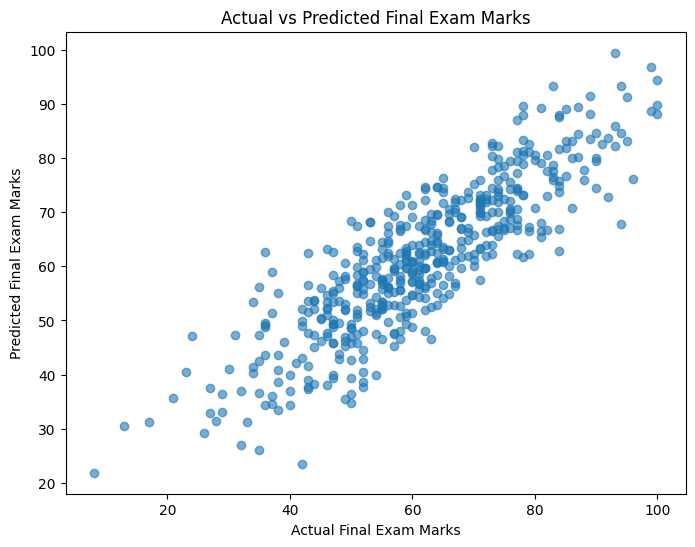

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Final Exam Marks")
plt.ylabel("Predicted Final Exam Marks")
plt.title("Actual vs Predicted Final Exam Marks")

plt.show()

### Interpretation

The Actual vs Predicted plot shows a clear positive relationship between the actual and predicted final exam marks.

Most observations are reasonably close to the expected diagonal pattern, indicating that the Linear Regression model captures a substantial portion of the relationship between the input features and final exam performance.

However, some predictions differ noticeably from the actual marks, which is consistent with the RMSE of 7.93 marks.

Overall, the Linear Regression model provides a useful baseline for predicting `Final_Exam_Marks`, with an R² score of 0.7462.

## Logistic Regression Classification

Logistic Regression is used to classify students into two categories:

- `Pass`
- `Fail`

The target variable is `Pass_Fail`.

`Final_Exam_Marks` is not used as an input feature because the pass/fail outcome is derived from the final exam result. Including it would cause target leakage.

In [13]:
# Define the classification target
y_class = df["Pass_Fail"].map({
    "Fail": 0,
    "Pass": 1
})

print("Classification target distribution:")
print(y_class.value_counts())

print("\nTarget labels:")
print(y_class.unique())

Classification target distribution:
Pass_Fail
1    2252
0     228
Name: count, dtype: int64

Target labels:
[1 0]


In [14]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X,
    y_class,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train_cls.shape)
print("Testing features:", X_test_cls.shape)
print("Training target:", y_train_cls.shape)
print("Testing target:", y_test_cls.shape)

Training features: (1984, 15)
Testing features: (496, 15)
Training target: (1984,)
Testing target: (496,)


## Classification Data Preprocessing

The same feature preprocessing approach is applied to the classification task.

- Numerical features are standardized using `StandardScaler`.
- Categorical features are encoded using `OneHotEncoder`.
- The preprocessing pipeline is fitted only on the training data.

In [15]:
preprocessor_cls = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_train_cls_processed = preprocessor_cls.fit_transform(X_train_cls)
X_test_cls_processed = preprocessor_cls.transform(X_test_cls)

print("Processed classification training shape:",
      X_train_cls_processed.shape)

print("Processed classification testing shape:",
      X_test_cls_processed.shape)

Processed classification training shape: (1984, 25)
Processed classification testing shape: (496, 25)


## Logistic Regression Model

Logistic Regression is used to classify students as either `Pass` or `Fail`.

The model is trained using the preprocessed training data and then evaluated on the unseen testing data.

In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_cls_processed,
    y_train_cls
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [17]:
y_pred_cls = logistic_model.predict(X_test_cls_processed)

print("Number of predictions:", len(y_pred_cls))

print("\nFirst 20 predictions:")
print(y_pred_cls[:20])

Number of predictions: 496

First 20 predictions:
[0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


## Logistic Regression Evaluation

The Logistic Regression model is evaluated using:

- **Accuracy:** Percentage of correctly classified students.
- **Precision:** Proportion of predicted Pass students who actually passed.
- **Recall:** Proportion of actual Pass students correctly identified by the model.
- **F1-score:** Harmonic mean of precision and recall.

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test_cls, y_pred_cls)
precision = precision_score(y_test_cls, y_pred_cls)
recall = recall_score(y_test_cls, y_pred_cls)
f1 = f1_score(y_test_cls, y_pred_cls)

print("Logistic Regression Performance")
print("-" * 38)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Logistic Regression Performance
--------------------------------------
Accuracy  : 0.9335
Precision : 0.9587
Recall    : 0.9692
F1-score  : 0.9639


## Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each class.

For this classification problem:

- **0 = Fail**
- **1 = Pass**

The matrix helps us understand how well the model distinguishes between students who pass and fail.

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_cls, y_pred_cls)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 22  19]
 [ 14 441]]


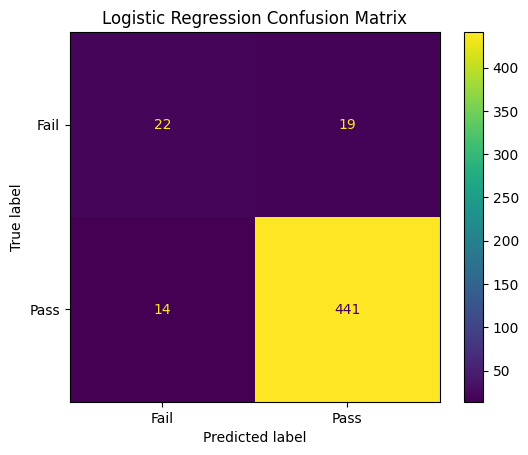

In [20]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the model correctly classified 22 students as Fail and 441 students as Pass.

The model incorrectly classified 19 students who actually failed as Pass, while 14 students who actually passed were classified as Fail.

Overall, the model correctly classified 463 out of 496 test samples, which is consistent with the high classification performance observed in the evaluation metrics.

## Model Performance Summary

The project uses two machine learning approaches:

1. **Linear Regression** for predicting continuous `Final_Exam_Marks`.
2. **Logistic Regression** for classifying students as `Pass` or `Fail`.

The performance of both models is summarized below.

In [21]:
model_summary = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Logistic Regression"
    ],
    "Task": [
        "Final Exam Marks Prediction",
        "Pass/Fail Classification"
    ],
    "Primary Metric": [
        f"R² = {r2:.4f}",
        f"F1-score = {f1:.4f}"
    ]
})

display(model_summary)

,Model,Task,Primary Metric
0,Linear Regression,Final Exam Marks Prediction,R² = 0.7462
1,Logistic Regression,Pass/Fail Classification,F1-score = 0.9639


## Conclusion

Two machine learning models were developed to analyze student performance.

### Linear Regression

Linear Regression was used to predict `Final_Exam_Marks`.

The model achieved:

- MAE: 6.2976
- MSE: 62.8945
- RMSE: 7.9306
- R²: 0.7462

The R² score indicates that the model explains approximately 74.62% of the variation in final exam marks.

### Logistic Regression

Logistic Regression was used to classify students as `Pass` or `Fail`.

The model achieved:

- Accuracy: 93.35%
- Precision: 95.87%
- Recall: 96.92%
- F1-score: 96.39%

The confusion matrix showed that 463 out of 496 test samples were classified correctly.

Overall, the machine learning models demonstrate that the available academic and student-related features contain useful information for predicting final exam performance and classifying student outcomes.